In [1]:
#here I import the neccessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Task 3

In [2]:
bank_data = pd.read_csv('bank-additional-full.csv', sep=';') #including the CSV file separated by commas
display(bank_data.head(100)) #printing out the first hundred rows of data

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,45,services,married,professional.course,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
96,42,management,married,university.degree,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
97,53,admin.,divorced,university.degree,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
98,37,technician,single,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


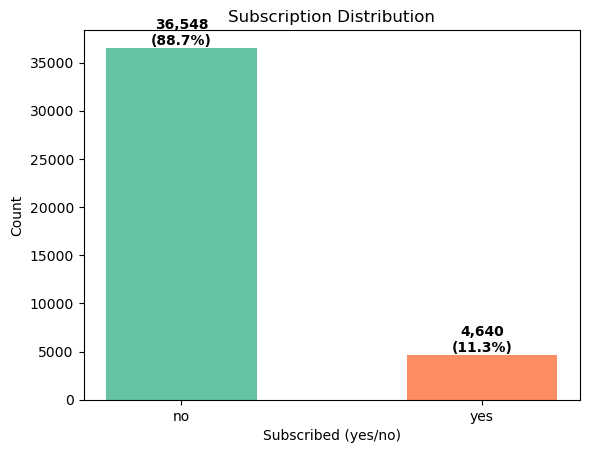

In [8]:
#Plot of the target variable
counts = bank_data['y'].value_counts()
plt.bar(counts.index, counts.values, color=['#66c2a5', '#fc8d62'], width=0.5)
plt.title('Subscription Distribution')
plt.xlabel('Subscribed (yes/no)')
plt.ylabel('Count')
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():,.0f}\n({p.get_height()/len(bank_data)*100:.1f}%)',
                       (p.get_x() + p.get_width()/2, p.get_height()),
                       ha='center', va='bottom', fontweight='bold')
plt.show()

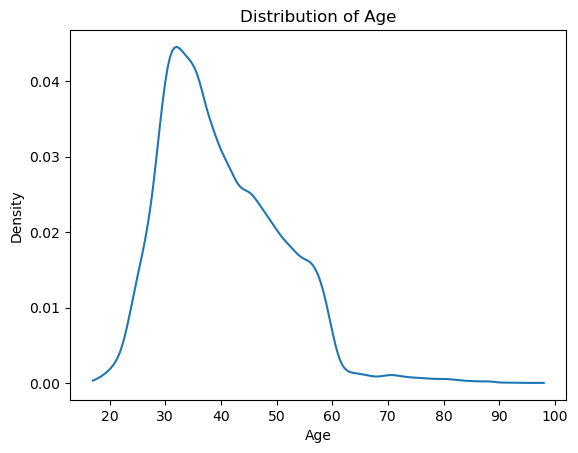

In [9]:
# two numerical variable plot

# first choice is age
from scipy.stats import gaussian_kde

kde = gaussian_kde(bank_data['age'])
x = np.linspace(bank_data['age'].min(), bank_data['age'].max(), 200)
plt.plot(x, kde(x))
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()
#I chose this specific plot type, because when I used barplots before, it was too dense

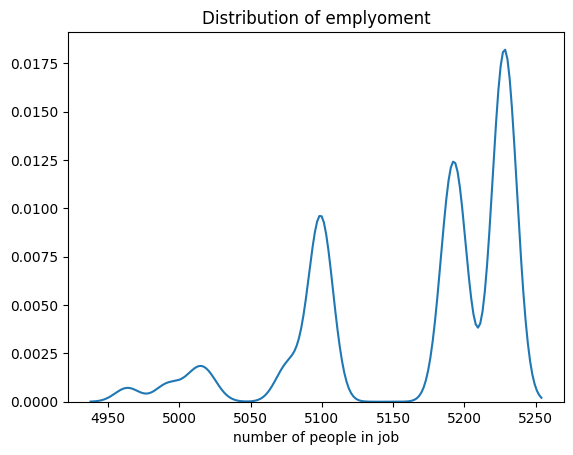

In [21]:
#second choice -> employment distribution
sns.kdeplot(x='nr.employed', data=bank_data)
plt.title('Distribution of emplyoment')
plt.xlabel('number of people in job')
plt.ylabel('')
plt.show()

/tmp/ipython-input-594/2181905311.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='job', data=bank_data, palette='Set2')


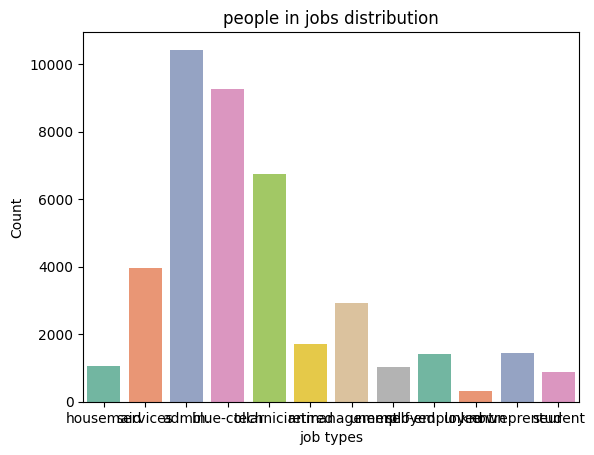

In [22]:
# two categorical variable plot
# first choice is job
sns.countplot(x='job', data=bank_data, palette='Set2')
plt.title('people in jobs distribution')
plt.xlabel('job types')
plt.ylabel('Count')
plt.show()

/tmp/ipython-input-594/122631489.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='marital', data=bank_data, palette='Set2')


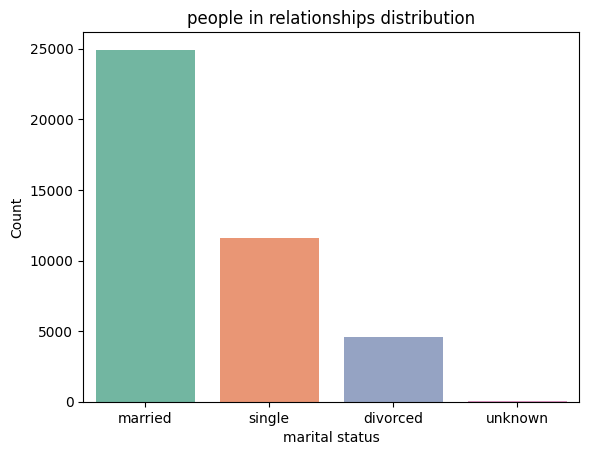

In [24]:
#second choice of categorical variable
sns.countplot(x='marital', data=bank_data, palette='Set2')
plt.title('people in relationships distribution')
plt.xlabel('marital status')
plt.ylabel('Count')
plt.show()

# Task 4 Managing Missing Values

• Quantify the extent of missingness for each affected variable.


In [3]:
df = pd.read_csv("bank-additional-full.csv", usecols=['default'])

default_counts = df['default'].value_counts()

ValueError: Usecols do not match columns, columns expected but not found: ['default']

# Task 5: Encoding Categorical Variables

Lecture material: Lecture 4 (Categorical Encoding), Lecture 6 (Linear Models), Lecture 9 (Feature Engineering
and Expressiveness).

• Identify all categorical variables in the dataset.

• Distinguish between nominal variables (categories without intrinsic order, e.g., job type) and ordinal variables
(categories with a meaningful order, e.g., education level), and justify your classification.

• Select and apply an appropriate encoding strategy for each categorical variable.

• Clearly state which encoders must be fitted on the training set only, and explain why.

• Analyze how encoding changes:

    – the dimensionality of the dataset;
    – the interpretability of model coefficients;
    – the types of decision boundaries a linear model can represent.

Note: Encoding is not a purely mechanical transformation. Your justification should explicitly connect your encoding
decisions to the assumptions and behavior of Logistic Regression

# Task 6: Feature Selection
Lecture material: Lecture 5 (Feature Selection), Lecture 6 (Linear Models), Lecture 9 (Pipeline Discipline).

• Identify and remove features with very low variance, if any. Justify the criterion used to define “low” variance.

• Identify highly correlated numerical features and decide whether any should be removed. Clearly state the
threshold used and justify your decision.

• Discuss whether any features should be removed based on conceptual considerations (e.g., redundancy,
availability at prediction time, or risk of data leakage).

• Explain why feature selection must be performed using the training set only.

• Discuss the consequences of performing feature selection on the entire dataset before splitting.
Note: Feature selection is not purely statistical. Your reasoning should explicitly connect your decisions to the assumptions and stability of Logistic Regression

# Task 7: Data Splitting
Lecture material: Lecture 2 (Data Splitting and Leakage), Lecture 9 (ML Pipeline).

• Split the dataset into training, validation, and test sets.

• Justify your choice of proportions for each split.

• Perform stratified splitting with respect to the target variable and explain why stratification is necessary for
this dataset.

• Clearly describe at which stage of your pipeline the split must occur, and explain what types of data leakage
would arise if splitting were performed later.

Note: A recommended strategy is to first split the dataset into a training set and a temporary set, and then
split the temporary set into validation and test sets. Use the stratify argument of train test split where
appropriate

# Task 8 Addressing Class Imbalance

Lecture material: Lecture 3 (Class Imbalance), Lecture 4 (Evaluation Metrics), Lecture 9 (Pipeline Discipline).

• Quantify the class distribution in the training set and explain why imbalance is or is not a concern for this
prediction task.

• Propose and apply a resampling strategy (e.g., random oversampling, SMOTE, or ADASYN). Clearly justify
at which stage of the pipeline the resampling step should occur.

• Justify your choice of resampling method in terms of its assumptions and expected effect on the learning
algorithm.

• Explain what would happen if resampling were applied before splitting the dataset into training, validation,
and test sets. Discuss the implications for model evaluation.

• Briefly discuss how class imbalance affects evaluation metrics such as accuracy, precision, and recall.

Note: Resampling is part of the training procedure and must be applied to the training set only. Validation and
test sets must preserve the original class distribution

# Task 9: Feature Scaling

Lecture material: Lecture 5 (Feature Scaling), Lecture 6 (Logistic Regression and Optimization)..

• Identify the numerical variables that require scaling.

• Select and apply an appropriate scaling strategy (e.g., standardization or normalization) to those variables.

• Justify your choice of scaling method in the context of Logistic Regression.

• Clearly state which transformations must be fitted on the training set only, and explain why.

• Discuss how feature scaling affects

    – gradient-based optimization;
    – the magnitude and comparability of model coefficients;
    – the interpretation of regularization penalties.

Note: Feature scaling is not a cosmetic transformation. Your justification should explicitly connect your scaling
decision to the mathematical behavior of linear models

# training a Logistic Regression Model

Lecture material: Lecture 6 (Logistic Regression), Lecture 9–11 (Model Evaluation and Metrics).
• Train a Logistic Regression model to predict whether a client subscribes to a term deposit.
• Use the validation set to generate predictions.
• Report at least Accuracy, Precision, and Recall on the validation set.
• Compare the model’s accuracy with the Zero Rule baseline and briefly interpret the result.
Note: The goal here is not to squeeze out the best possible performance. The goal is to verify that your data
preparation pipeline is coherent and correctly implemented. If your preprocessing is principled, the model should
behave sensibly. If it behaves strangely, that is a signal to revisit earlier decisions. Have fun finding a visually
appealing way to display the predictions or the confusion matrix on the validation set. This is your chance to make
the output readable and professional 8-)